In [19]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df = pd.read_csv('resultados copy.csv', sep=',')
df=df[1:]

grafos = df['Grafo'].unique().tolist()
algoritmos = df['Algoritmo'].unique().tolist()
vetor_df = []
for g in grafos:
    for a in algoritmos:
        dfTemp = df.loc[df['Grafo'] == g].loc[df['Algoritmo'] == a]
        vetor_df.append([g, a, dfTemp])

display(len(vetor_df))





12

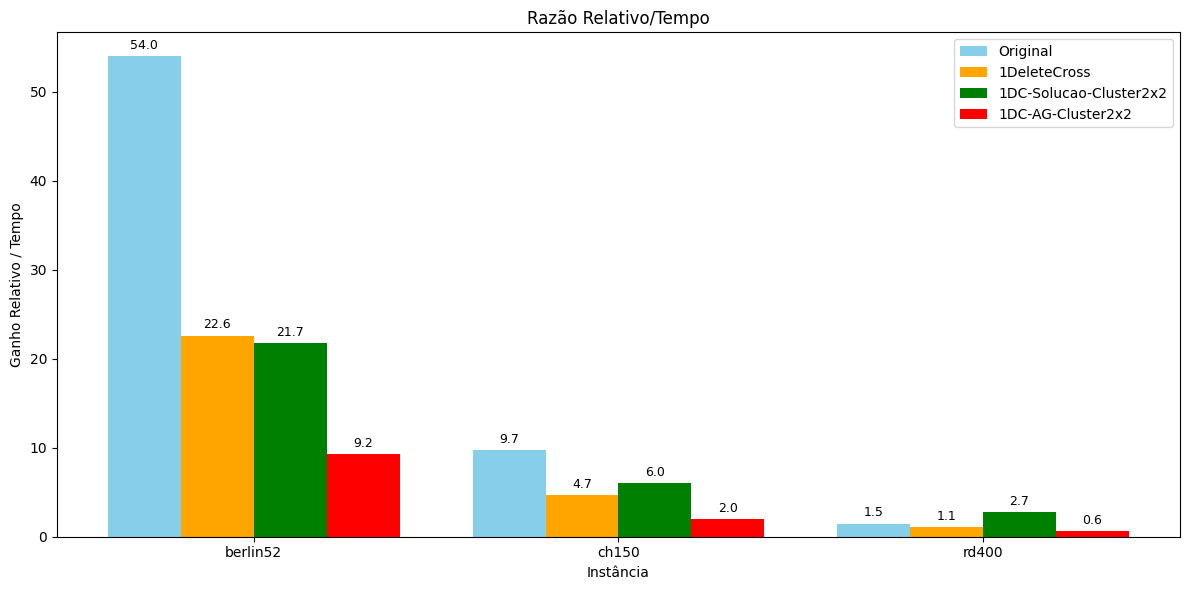

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dados
data = {
    "Grafo": ["berlin52","berlin52","berlin52","berlin52",
              "ch150","ch150","ch150","ch150",
              "rd400","rd400","rd400","rd400"],
    "Algoritmo": ["Original","1DeleteCross","1DC-Solucao-Cluster2x2","1DC-AG-Cluster2x2",
                  "Original","1DeleteCross","1DC-Solucao-Cluster2x2","1DC-AG-Cluster2x2",
                  "Original","1DeleteCross","1DC-Solucao-Cluster2x2","1DC-AG-Cluster2x2"],
    "Tempo": [0.888623, 2.807173, 2.716884, 6.827652,
              4.252273, 12.897952, 13.556577, 41.086645,
              24.927746, 55.361869, 29.818574, 132.675482],
    "GanhoRelativo": [47.954352, 63.356803, 59.037421, 63.118880,
                      41.203219, 60.390660, 81.299773, 81.214126,
                      36.551050, 59.086783, 81.500066, 81.631404]
}

df = pd.DataFrame(data)

# Calcula a razão Ganho/Tempo
df["Ganho_por_Tempo"] = df["GanhoRelativo"] / df["Tempo"]

# Configuração das barras
algoritmos = df["Algoritmo"].unique()
cores = ["skyblue", "orange", "green", "red"]
largura = 0.2

# Posições no eixo x
grafo_unicos = df["Grafo"].unique()
x = np.arange(len(grafo_unicos))

plt.figure(figsize=(12,6))

for i, algoritmo in enumerate(algoritmos):
    valores = df[df["Algoritmo"] == algoritmo]["Ganho_por_Tempo"]
    barras = plt.bar(x + i*largura, valores, width=largura, label=algoritmo, color=cores[i])
    
    # Adiciona rótulos em cima das barras
    for barra in barras:
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, altura + 0.5, f"{altura:.1f}", 
                 ha='center', va='bottom', fontsize=9)

plt.xticks(x + largura*1.5, grafo_unicos)
plt.xlabel("Instância")
plt.ylabel("Ganho Relativo / Tempo")
plt.title("Razão Relativo/Tempo")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/grafico_ganho_por_tempo.png")
plt.show()


## Comparativo todos cenarios   

In [21]:
dfGeral = pd.DataFrame(columns=['Grafo', 'Algoritmo', 'Fit Inicial Médio', 'Fit Melhor Médio', 'Tempo Execução Médio (s)', 'Ganho Relativo Médio (%)'])



for df in vetor_df:
    tempo_execucao = []
    ganho_relativo = []
    grafo = df[0]
    algoritmo = df[1][3:]
    texto = (grafo + algoritmo).replace(" ", "_").replace("-", "_")
    dataframe = df[2]
    fit_inicial_medio = np.mean(dataframe['Fit Inicial'].astype(float))
    fit_melhor_medio = np.mean(dataframe['Fit Final'].astype(float))
    tempo = np.mean(dataframe['Tempo Execução (s)'].astype(float))
    tempo_execucao.append(tempo)
    tempo_execucao_medio = tempo
    ganho = np.mean(dataframe['Ganho Relativo (%)'].astype(float))
    ganho_relativo.append(ganho)
    ganho_relativo_medio = ganho

    dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)
    

dfGeral = dfGeral.sort_values(by=['Grafo', 'Algoritmo'], ascending=[True, False])
dfGeral.to_csv('tabelas/resultados_geral.csv', index=False)
dfGeral.to_latex('tabelas/resultados_geral.tex', index=False, float_format="%.2f")

display(dfGeral)


/tmp/ipykernel_195241/2024354338.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)


,Grafo,Algoritmo,Fit Inicial Médio,Fit Melhor Médio,Tempo Execução Médio (s),Ganho Relativo Médio (%)
3,berlin52,Original,25874.493078,13453.634463,0.888623,47.954352
0,berlin52,1DeleteCross,25920.393626,9483.369918,2.807173,63.356803
1,berlin52,1DC-Solucao-Cluster2x2,26040.306133,10662.712851,2.716884,59.037421
2,berlin52,1DC-AG-Cluster2x2,25875.963890,9540.231471,6.827652,63.118880
7,ch150,Original,49142.677755,28886.392985,4.252273,41.203219
4,ch150,1DeleteCross,49201.458111,19481.414232,12.897952,60.390660
5,ch150,1DC-Solucao-Cluster2x2,49167.151634,9194.532013,13.556577,81.299773
6,ch150,1DC-AG-Cluster2x2,49237.511212,9248.636348,41.086645,81.214126
11,rd400,Original,200077.116947,126943.520504,24.927746,36.551050
8,rd400,1DeleteCross,200834.908280,82159.237711,55.361869,59.086783


# Comparativo por Cluster

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_195241/1369077596.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, valores_tempo, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")


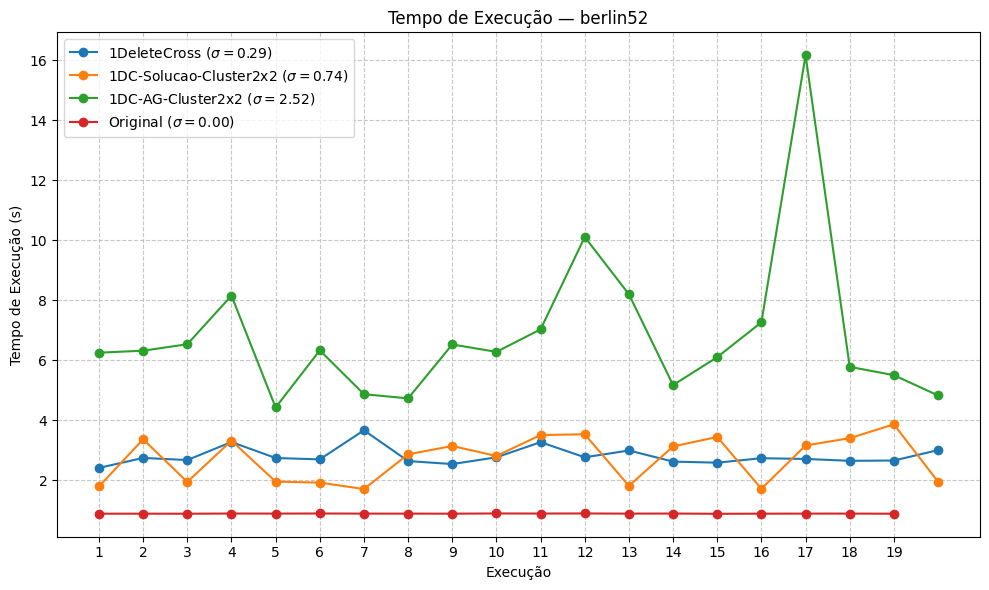

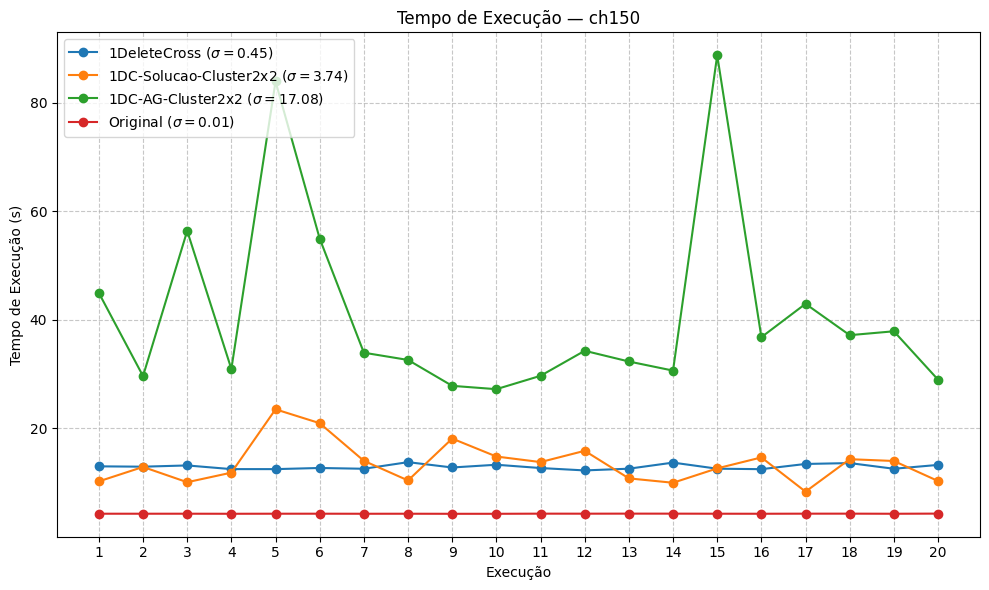

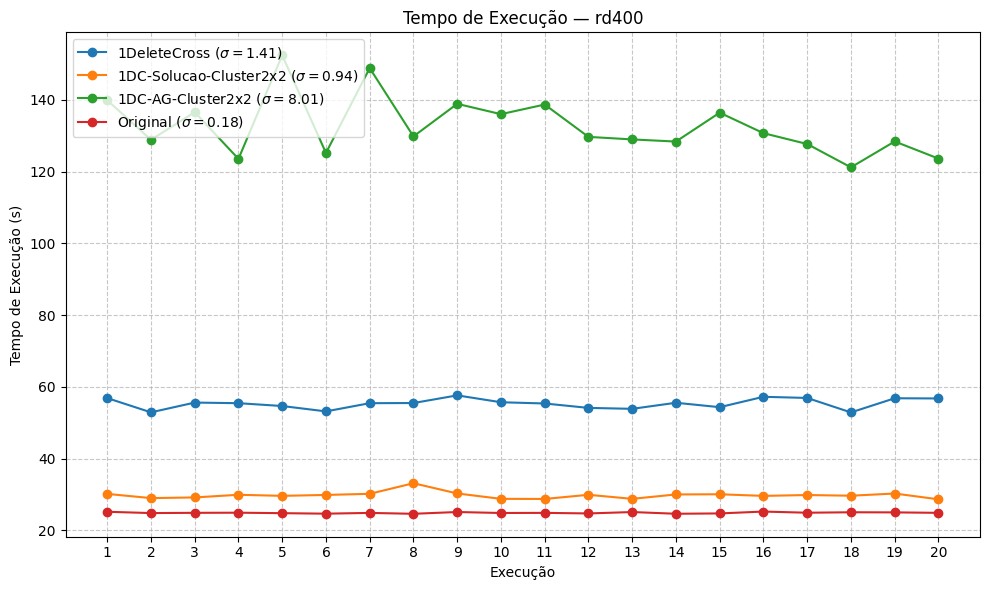

In [22]:
import matplotlib.pyplot as plt
import numpy as np

title = True
extensao = ".png"

plt.style.use('fast')

for g in grafos:
    vetor = [item for item in vetor_df if item[0] == g]

    plt.figure(figsize=(10, 6))

    for item in vetor:
        algoritmo = item[1][3:].replace(" ", "_")
        dftemp = item[2]
        valores_tempo = dftemp['Tempo Execução (s)'].astype(float).tolist()

        n = len(valores_tempo)
        x = list(range(1, n + 1))

        dp = np.std(valores_tempo)
        plt.plot(x, valores_tempo, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")

    plt.xticks(ticks=list(range(1, n + 1)), labels=list(range(1, n + 1)))
    plt.xlabel("Execução")
    plt.ylabel("Tempo de Execução (s)")

    if title:
        plt.title(f"Tempo de Execução — {g}")

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)

    nome_arquivo = f"graficos/tempos_execucao_{g}{extensao}"
    plt.savefig(nome_arquivo, dpi=150)
    #plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_195241/2129063788.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, valores_ganho, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")


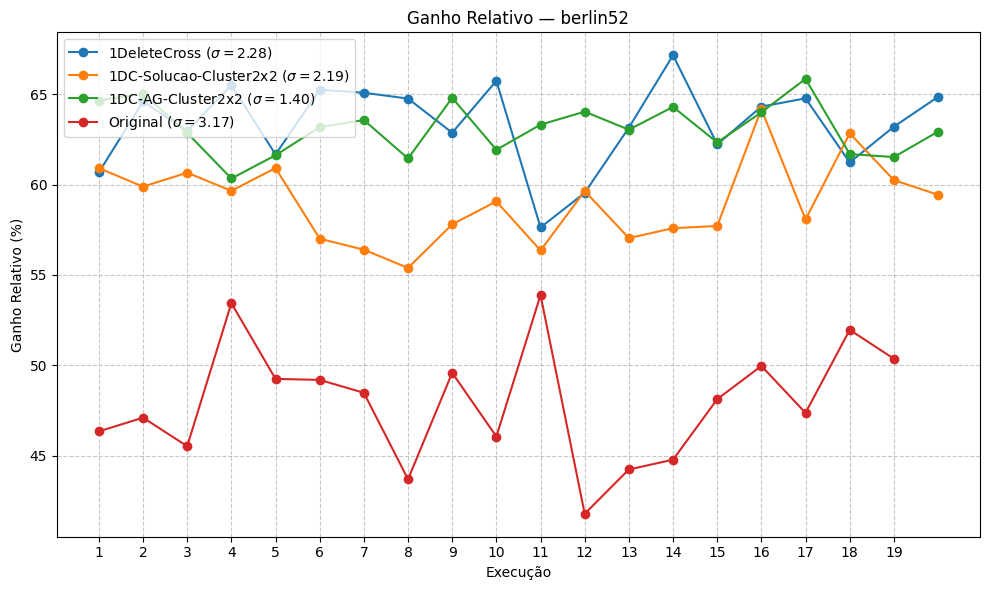

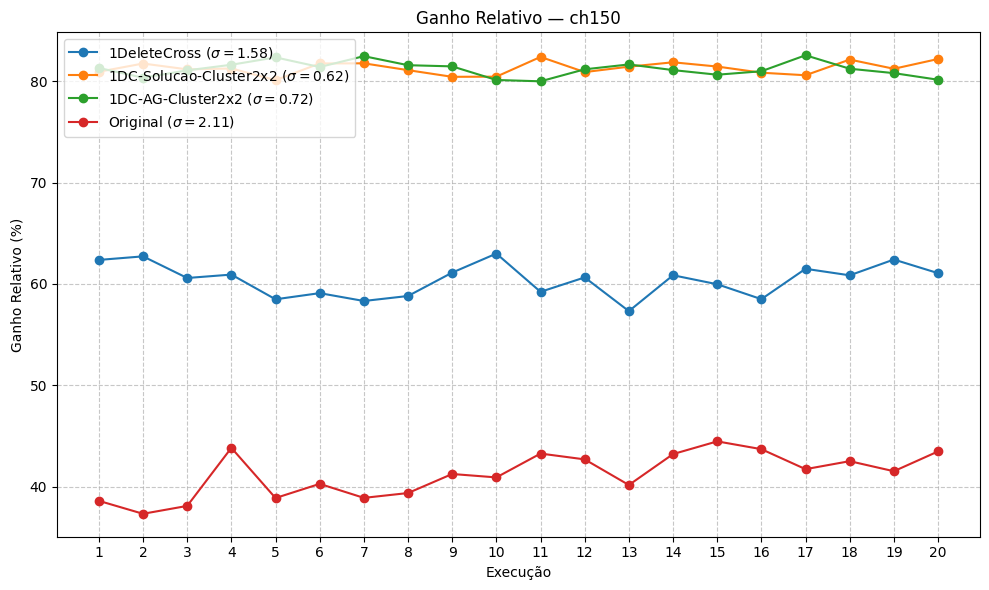

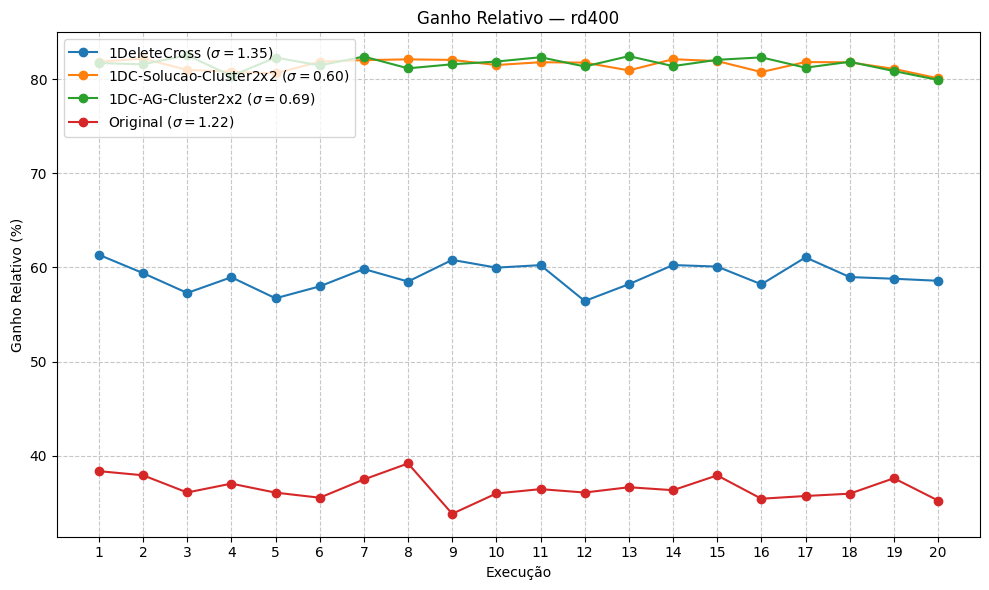

In [23]:
import numpy as np
import matplotlib.pyplot as plt

title = True
extensao = ".png"

plt.style.use('fast')

for g in grafos:
    vetor = [item for item in vetor_df if item[0] == g]

    plt.figure(figsize=(10, 6))
    for item in vetor:
        algoritmo = item[1][3:].replace(" ", "_")
        dftemp = item[2]
        valores_ganho = dftemp['Ganho Relativo (%)'].astype(float).tolist()

        n = len(valores_ganho)
        x = list(range(1, n + 1))

        dp = np.std(valores_ganho)
        plt.plot(x, valores_ganho, marker="o", label=f"{algoritmo} ($\sigma={dp:.2f}$)")

    plt.xticks(ticks=list(range(1, n + 1)), labels=list(range(1, n + 1)))
    plt.xlabel("Execução")
    plt.ylabel("Ganho Relativo (%)")

    if title:
        plt.title(f"Ganho Relativo — {g}")

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)

    nome_arquivo = f"graficos/ganho_relativo{g}{extensao}"
    plt.savefig(nome_arquivo, dpi=150)
    plt.show()
